# 12 - Structure-distance end-to-end showcase (semantic SMD + structural Wasserstein, E08-H44)

**Author** - kj &nbsp;|&nbsp; **Approach** - position-augmented optimal transport, the surviving E08-H44 mechanism

Demonstrates the two-axis design of [`docs/wmd-structure-distance-sota.md`](../docs/wmd-structure-distance-sota.md) on real
executive-summary statements. For a pair of documents it computes **both** distances off one set of embeddings and one
solver, and recovers the structural mapping with per-statement interpretability:

- **Semantic distance** - Statement Mover's Distance, the order-invariant content axis; position-augmented Wasserstein at `lambda=0`
- **Structural distance** - position-augmented Wasserstein at `lambda=0.25` (the **E08-H44** headline weight), order-sensitive
- **Structural mapping** - the transport plan `T` couples A's statements to B's; each statement's induced position `tau(i)` and
  displacement `delta(i)` name the movers - the structural analogue of SMD's transport-map JSON

Three contrasting pairs make the two axes legible: a **reordered-but-faithful** pair (content preserved, arrangement changed -
the case SMD misses), a **different-content** pair (SMD fires), and an **identity** sanity pair (both axes saturate at closeness 1).

## GPU selection

mmBERT statement embedding runs on the RTX 5000 Ada (GPU 2), pinned by UUID - the same device E07/E08 used. The optimal-transport
math is CPU numpy, so the GPU only accelerates the single embedding pass over a handful of statements.

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-c15a4c9a-8c2c-7fb9-a46b-fe4dff5dacf4"  # RTX 5000 Ada
os.environ["TOKENIZERS_PARALLELISM"] = "false"; os.environ["TRANSFORMERS_VERBOSITY"] = "error"; os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import warnings; warnings.filterwarnings("ignore")
import torch
print("torch", torch.__version__, "| cuda:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch 2.12.1+cu130 | cuda: True | NVIDIA RTX 5000 Ada Generation


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table

import ot
from docdistance.distance import transport_plan, cost_matrix, smd, closeness, SMD_MAX
from docdistance.encoders import load_encoder, Segmenter

console = Console()
sns.set_theme(style="whitegrid", context="notebook")
print("imports ready | POT", ot.__version__)

imports ready | POT 0.9.6.post1


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED)
print(f"SEED={SEED}")

SEED=0


## Configuration

Paths, the structural weight, the mover threshold, and the models in one place. `LAM_STRUCT=0.25` is the **E08-H44** headline
weight reported in the SOTA doc; `LAM_SEM=0.0` reproduces SMD exactly (the semantic special case). The encoder is the torch CUDA
mmBERT (mean-pooled, L2-normalized - the same vectors SMD uses); the segmenter is `sat-3l-sm` on CPU. The resolved device is shown
in the table.

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
SUMMARY_DIR = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/summaries"
FIGDIR = ROOT / "reports/figures/12-e2e"; FIGDIR.mkdir(parents=True, exist_ok=True)

LAM_SEM = 0.0        # position-augmented Wasserstein at lambda=0 == SMD (semantic, order-invariant)
LAM_STRUCT = 0.25    # E08-H44 headline structural weight (order-sensitive)
MOVER_THRESH = 0.10  # |delta| (normalized position) above this flags a statement as a mover

DOC_A_FILE = "exec-summary-gold-opus-4-8.md"   # the base document (gold)
DOC_B_FILE = "exec-summary-sonnet-4-6.md"      # the different-content counterpart (another base)
REORDER_SWAPS = 5                              # seeded transpositions for the reordered-but-faithful pair

# load the models once - torch CUDA encoder (offline=False) + SAT segmenter (CPU)
ENC = load_encoder("torch", offline=False, device="cuda")
SEG = Segmenter()
DEVICE = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

t = Table(title="Notebook 12 configuration", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
t.add_column(style="bold cyan"); t.add_column()
t.add_row("Device", DEVICE)
t.add_row("Encoder", "mmBERT torch CUDA - mean-pooled, L2-normalized (same vectors as SMD)")
t.add_row("Segmenter", "sat-3l-sm (wtpsplit, CPU)")
t.add_row("Semantic lambda", f"{LAM_SEM}  (position-augmented Wasserstein at 0 == SMD)")
t.add_row("Structural lambda", f"{LAM_STRUCT}  (E08-H44 headline weight)")
t.add_row("Mover threshold", f"|delta| > {MOVER_THRESH} normalized position")
t.add_row("Closeness", "1 - d / sqrt(2),  sqrt(2) = " + f"{SMD_MAX:.4f}")
t.add_row("Figures", str(FIGDIR))
console.print(t)

                                    Notebook 12 configuration                                    
  Device               NVIDIA RTX 5000 Ada Generation                                            
  Encoder              mmBERT torch CUDA - mean-pooled, L2-normalized (same vectors as SMD)      
  Segmenter            sat-3l-sm (wtpsplit, CPU)                                                 
  Semantic lambda      0.0  (position-augmented Wasserstein at 0 == SMD)                         
  Structural lambda    0.25  (E08-H44 headline weight)                                           
  Mover threshold      |delta| > 0.1 normalized position                                         
  Closeness            1 - d / sqrt(2),  sqrt(2) = 1.4142                                        
  Figures              /home/lab/workspace/learning/projects/docdistance/reports/figures/12-e2e

## Distance and mapping functions

The structural cost fuses the semantic chord distance with normalized statement position into one metric
`M_tilde = sqrt((1-lambda) d_sem^2 + lambda d_pos^2)`; `posaug_cost` / `posaug_smd` are reused verbatim from E08. The plan under
`M_tilde` is the structural mapping: for each A-statement its induced target position `tau(i)` and displacement `delta(i)` are an
`O(n)` read off the already-computed plan.

In [5]:
def pos_vec(n):
    """Normalized statement positions i/(n-1) in [0,1] - comparable across documents of any length."""
    return np.arange(n) / max(n - 1, 1)

# --- E08-H44 position-augmented cost and Wasserstein distance (verbatim from E08) ---
def posaug_cost(EA, EB, lam, posA=None, posB=None):
    d_sem = cost_matrix(EA, EB)                          # sqrt(2-2cos) in [0,2]
    pa = pos_vec(len(EA)) if posA is None else posA
    pb = pos_vec(len(EB)) if posB is None else posB
    d_pos = np.abs(pa[:, None] - pb[None, :])           # |normalized position delta| in [0,1]
    return np.sqrt((1 - lam) * d_sem ** 2 + lam * d_pos ** 2)

def posaug_smd(EA, EB, lam, posA=None, posB=None):
    a, b = np.full(len(EA), 1 / len(EA)), np.full(len(EB), 1 / len(EB))
    return float(ot.emd2(a, b, posaug_cost(EA, EB, lam, posA, posB)))

def posaug_plan(EA, EB, lam, posA=None, posB=None):
    """The exact OT coupling under M_tilde; lambda=0 == the SMD transport_plan, lambda>0 == the structural mapping."""
    a, b = np.full(len(EA), 1 / len(EA)), np.full(len(EB), 1 / len(EB))
    return ot.emd(a, b, posaug_cost(EA, EB, lam, posA, posB))

def induced_mapping(T, posB):
    """tau(i) = sum_j T_ij pos_j / sum_j T_ij  (transport-weighted target position) and the matched B-index per A-statement."""
    tau = (T @ posB) / (T.sum(1) + 1e-12)
    matched = T.argmax(1)
    return tau, matched

def trunc(s, n=44):
    s = s.replace("\n", " ").strip()
    return s if len(s) <= n else s[: n - 1] + "."

print("functions defined")

functions defined


## Documents and pairs

Each markdown summary is split into paragraph blocks, then `sat-3l-sm` segments every block into statements - the same
segment-then-embed pipeline E07/E08 use. The base document (`gold`) is segmented once; the **reordered-but-faithful** counterpart
is a seeded transposition of those same statements (identical content, rearranged), so its embeddings are a permutation of the
base's. The **different-content** counterpart is a second base summary (`sonnet`); the **identity** pair is the base against
itself.

In [6]:
def segment_doc(filename):
    """Paragraph-block then SAT-statement segmentation of a markdown summary - returns the flat statement list."""
    text = (SUMMARY_DIR / filename).read_text()
    blocks = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]
    statements = []
    for b in blocks:
        statements.extend(SEG.split(b))
    return statements

ST_A = segment_doc(DOC_A_FILE)   # gold
ST_B = segment_doc(DOC_B_FILE)   # sonnet
nA = len(ST_A)

# seeded reorder of gold's own statements (faithful content, rearranged order)
rng = np.random.default_rng(SEED)
perm = np.arange(nA)
for _ in range(REORDER_SWAPS):
    i, j = int(rng.integers(0, nA)), int(rng.integers(0, nA))
    perm[i], perm[j] = perm[j], perm[i]
ST_A_REORDERED = [ST_A[p] for p in perm]

# normalized-footrule displacement of the reorder (0 identity, ~1 reversal)
reorder_disp = float(np.abs(perm - np.arange(nA)).sum()) / (nA * nA // 2)

t = Table(title="Documents", title_style="bold cyan")
for c in ("label", "source", "statements"):
    t.add_column(c, style="cyan" if c == "label" else None)
t.add_row("gold", DOC_A_FILE, str(nA))
t.add_row("gold (reordered)", f"{REORDER_SWAPS} seeded swaps of gold, footrule disp {reorder_disp:.3f}", str(nA))
t.add_row("sonnet", DOC_B_FILE, str(len(ST_B)))
console.print(t)
print(f"reorder permutation: {perm.tolist()}")

                                   Documents                                   
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ label            ┃ source                                      ┃ statements ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ gold             │ exec-summary-gold-opus-4-8.md               │ 14         │
│ gold (reordered) │ 5 seeded swaps of gold, footrule disp 0.347 │ 14         │
│ sonnet           │ exec-summary-sonnet-4-6.md                  │ 13         │
└──────────────────┴─────────────────────────────────────────────┴────────────┘

reorder permutation: [1, 4, 8, 7, 0, 5, 6, 3, 11, 9, 10, 2, 12, 13]


## Embedding

The base and the different-content document are embedded once on the GPU; the reordered document reuses the base embeddings under
the permutation (its statements are byte-identical to the base, only their positions differ). This is the order-isolation upper
bound from E08 - any semantic distance the reordered pair shows is numerical noise, so the structure axis alone carries the
signal.

In [7]:
EMB_A = ENC.encode(ST_A)         # gold
EMB_B = ENC.encode(ST_B)         # sonnet
EMB_A_REORDERED = EMB_A[perm]    # identical content, permuted positions

PAIRS = [
    {"name": "reordered-but-faithful", "doc_a": "gold", "doc_b": "gold (reordered)",
     "EA": EMB_A, "EB": EMB_A_REORDERED, "STA": ST_A, "STB": ST_A_REORDERED, "perm": perm},
    {"name": "different-content", "doc_a": "gold", "doc_b": "sonnet",
     "EA": EMB_A, "EB": EMB_B, "STA": ST_A, "STB": ST_B, "perm": None},
    {"name": "identity", "doc_a": "gold", "doc_b": "gold",
     "EA": EMB_A, "EB": EMB_A, "STA": ST_A, "STB": ST_A, "perm": None},
]
print(f"embedded gold {EMB_A.shape}, sonnet {EMB_B.shape} | dim {EMB_A.shape[1]} | {len(PAIRS)} pairs ready")

embedded gold (14, 768), sonnet (13, 768) | dim 768 | 3 pairs ready


## Two-axis readout - semantic vs structural

For every pair, both numbers come off the same embeddings and the same `ot.emd2` solver: SMD at `lambda=0` (semantic, the content
axis) and position-augmented Wasserstein at `lambda=0.25` (structural, order-sensitive), each mapped to closeness `1 - d/sqrt(2)`.
The reordered-but-faithful pair is the proof point - semantic closeness saturates near 1 (content preserved) while structural
closeness drops below it (arrangement changed), exactly the signal SMD misses.

In [8]:
rows = []
for p in PAIRS:
    posA, posB = pos_vec(len(p["EA"])), pos_vec(len(p["EB"]))
    d_sem = posaug_smd(p["EA"], p["EB"], LAM_SEM, posA, posB)        # == smd()
    d_struct = posaug_smd(p["EA"], p["EB"], LAM_STRUCT, posA, posB)
    rows.append({"pair": p["name"], "doc A": p["doc_a"], "doc B": p["doc_b"],
                 "n_A": len(p["EA"]), "n_B": len(p["EB"]),
                 "SMD (sem)": d_sem, "sem closeness": closeness(d_sem),
                 "struct dist": d_struct, "struct closeness": closeness(d_struct)})
readout = pd.DataFrame(rows)

t = Table(title="Two-axis readout - semantic (SMD, lambda=0) vs structural (position-augmented Wasserstein, lambda=0.25)",
          title_style="bold cyan")
for c in ("pair", "doc A -> doc B", "n", "SMD (sem)", "sem closeness", "struct dist", "struct closeness"):
    t.add_column(c, style="cyan" if c == "pair" else None, justify="left" if c in ("pair", "doc A -> doc B") else "right")
for r in rows:
    style = "bold yellow" if r["pair"] == "reordered-but-faithful" else None
    t.add_row(r["pair"], f'{r["doc A"]} -> {r["doc B"]}', f'{r["n_A"]}x{r["n_B"]}',
              f'{r["SMD (sem)"]:.4f}', f'{r["sem closeness"]:.3f}',
              f'{r["struct dist"]:.4f}', f'{r["struct closeness"]:.3f}', style=style)
console.print(t)

      Two-axis readout - semantic (SMD, lambda=0) vs structural (position-augmented Wasserstein, lambda=0.25)      
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ pair                 ┃ doc A -> doc B      ┃     n ┃ SMD (sem) ┃ sem closeness ┃ struct dist ┃ struct closeness ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ reordered-but-faith… │ gold -> gold        │ 14x14 │    0.0002 │         1.000 │      0.0935 │            0.934 │
│                      │ (reordered)         │       │           │               │             │                  │
│ different-content    │ gold -> sonnet      │ 14x13 │    0.3704 │         0.738 │      0.3294 │            0.767 │
│ identity             │ gold -> gold        │ 14x14 │    0.0000 │         1.000 │      0.0000 │            1.000 │
└──────────────────────┴─────────────────────┴───────┴───────────┴───────────────┴─────────────┴──────────────────┘

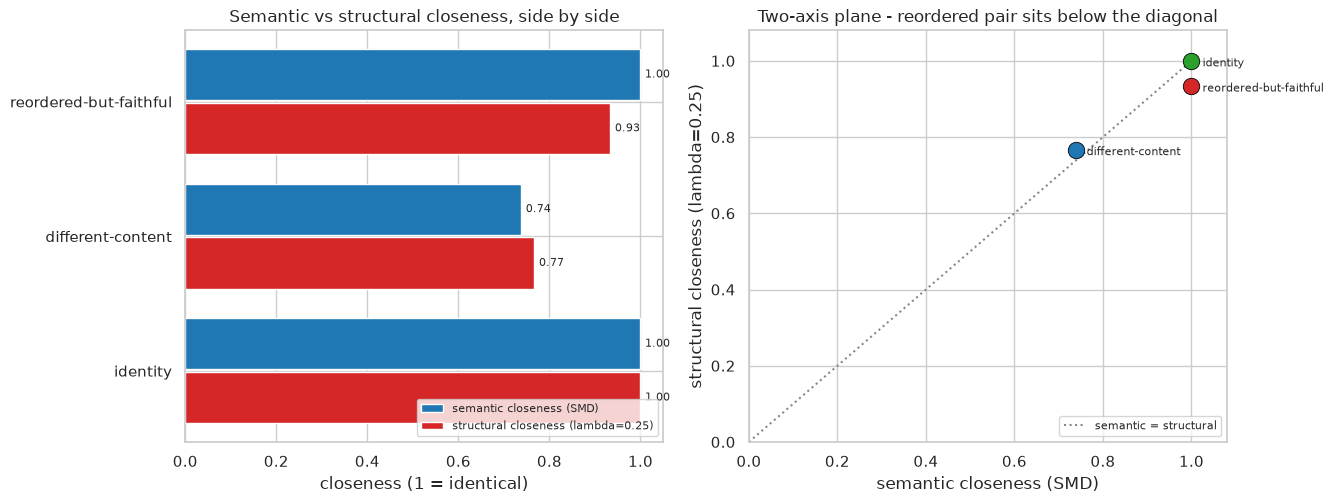

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2))
names = readout["pair"].tolist()
y = np.arange(len(names))
ax1.barh(y - 0.2, readout["sem closeness"], height=0.38, color="#1f77b4", label="semantic closeness (SMD)")
ax1.barh(y + 0.2, readout["struct closeness"], height=0.38, color="#d62728", label="structural closeness (lambda=0.25)")
ax1.set_yticks(y); ax1.set_yticklabels(names); ax1.invert_yaxis()
ax1.set(xlim=(0, 1.05), xlabel="closeness (1 = identical)", title="Semantic vs structural closeness, side by side")
for yi, (s, st) in enumerate(zip(readout["sem closeness"], readout["struct closeness"])):
    ax1.text(s + 0.01, yi - 0.2, f"{s:.2f}", va="center", fontsize=8)
    ax1.text(st + 0.01, yi + 0.2, f"{st:.2f}", va="center", fontsize=8)
ax1.legend(loc="lower right", fontsize=8)

ax2.plot([0, 1], [0, 1], ls=":", color="#888888", label="semantic = structural")
col = {"reordered-but-faithful": "#d62728", "different-content": "#1f77b4", "identity": "#2ca02c"}
for r in rows:
    ax2.scatter(r["sem closeness"], r["struct closeness"], s=140, color=col[r["pair"]], zorder=3, edgecolor="black", linewidth=0.6)
    ax2.annotate(r["pair"], (r["sem closeness"], r["struct closeness"]), textcoords="offset points",
                 xytext=(8, -4), fontsize=8)
ax2.set(xlim=(0, 1.08), ylim=(0, 1.08), xlabel="semantic closeness (SMD)", ylabel="structural closeness (lambda=0.25)",
        title="Two-axis plane - reordered pair sits below the diagonal")
ax2.legend(loc="lower right", fontsize=8)
plt.tight_layout(); fig.savefig(FIGDIR / "12-two-axis-readout.png", dpi=120, bbox_inches="tight"); plt.show()

## Structural mapping plan - the transport plan as the alignment

The transport plan `T` is the structural mapping: `T[i,j]` is the mass moved from A-statement `i` to B-statement `j`. For the
reordered-but-faithful pair both the semantic plan (`lambda=0`) and the structural plan (`lambda=0.25`) follow the content
permutation, so mass sits **off the diagonal** - each statement matched to its identical copy at its new position. The structural
plan is what the displacement read `tau(i)` is taken from.

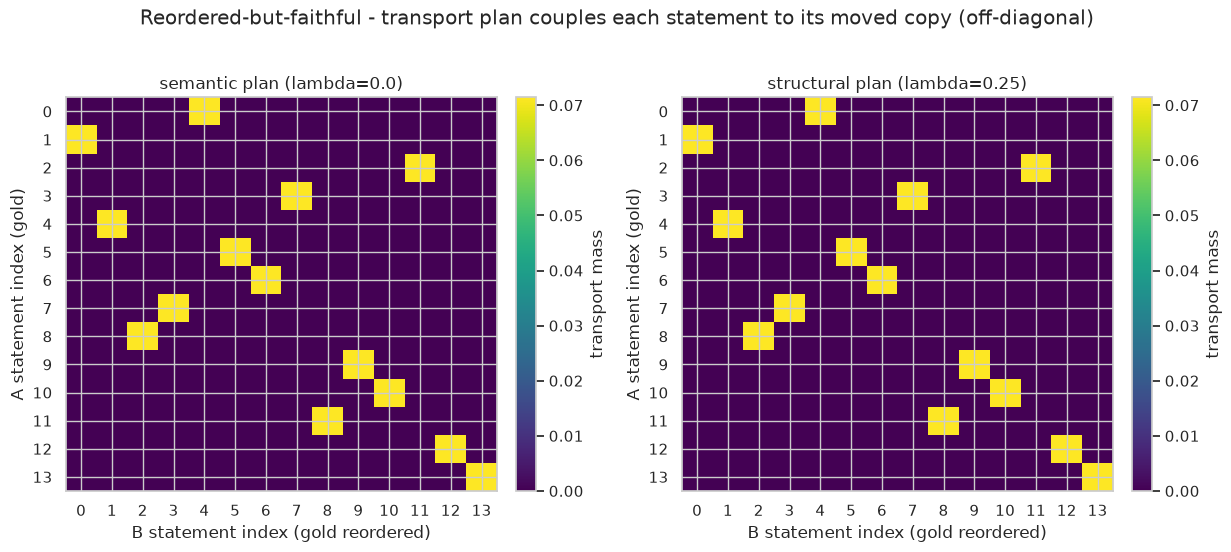

In [10]:
head = PAIRS[0]   # reordered-but-faithful
posA, posB = pos_vec(len(head["EA"])), pos_vec(len(head["EB"]))
T_sem = posaug_plan(head["EA"], head["EB"], LAM_SEM, posA, posB)
T_struct = posaug_plan(head["EA"], head["EB"], LAM_STRUCT, posA, posB)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
for ax, T, title in ((axes[0], T_sem, f"semantic plan (lambda={LAM_SEM})"),
                     (axes[1], T_struct, f"structural plan (lambda={LAM_STRUCT})")):
    im = ax.imshow(T, cmap="viridis", aspect="auto")
    ax.set(xlabel="B statement index (gold reordered)", ylabel="A statement index (gold)", title=title)
    ax.set_xticks(range(len(head["EB"]))); ax.set_yticks(range(len(head["EA"])))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="transport mass")
fig.suptitle("Reordered-but-faithful - transport plan couples each statement to its moved copy (off-diagonal)", y=1.02)
plt.tight_layout(); fig.savefig(FIGDIR / "12-transport-plans.png", dpi=120, bbox_inches="tight"); plt.show()

## Movers table - per-statement interpretability

The structural analogue of SMD's transport-map JSON. For each A-statement: its original normalized position, the B-statement its
mass lands on (argmax of the structural plan), its induced target position `tau(i)`, the displacement `delta(i) = tau(i) - pos_i`,
and a mover flag for `|delta| > 0.10`. On the reordered pair each statement matches its identical copy, so the matched B-text equals
the A-text and `delta` names exactly how far that statement was moved.

In [11]:
tau, matched = induced_mapping(T_struct, posB)
pos = pos_vec(len(head["EA"]))
delta = tau - pos
STA, STB = head["STA"], head["STB"]

movers_rows = []
for i in range(len(STA)):
    is_mover = abs(delta[i]) > MOVER_THRESH
    movers_rows.append({"i": i, "A statement": trunc(STA[i]), "pos": pos[i],
                        "matched B": trunc(STB[matched[i]]), "tau": tau[i], "delta": delta[i], "mover": is_mover})
movers_df = pd.DataFrame(movers_rows)
n_movers = int(movers_df["mover"].sum())

t = Table(title=f"Structural mapping - movers table (reordered-but-faithful, {n_movers}/{len(STA)} movers)",
          title_style="bold cyan")
for c, j in (("i", "right"), ("A statement", "left"), ("pos", "right"), ("matched B statement", "left"),
             ("tau", "right"), ("delta", "right"), ("mover", "center")):
    t.add_column(c, justify=j, overflow="fold")
for r in movers_rows:
    style = "bold red" if r["mover"] else None
    t.add_row(str(r["i"]), r["A statement"], f'{r["pos"]:.2f}', r["matched B"],
              f'{r["tau"]:.2f}', f'{r["delta"]:+.2f}', "YES" if r["mover"] else "-", style=style)
console.print(t)

top = movers_df.reindex(movers_df["delta"].abs().sort_values(ascending=False).index).head(3)
print("largest movers:")
for _, r in top.iterrows():
    print(f"  statement {int(r['i'])} at pos {r['pos']:.2f} -> tau {r['tau']:.2f} (delta {r['delta']:+.2f}): {r['A statement']}")

                      Structural mapping - movers table (reordered-but-faithful, 7/14 movers)                      
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┓
┃  i ┃ A statement                          ┃  pos ┃ matched B statement                   ┃  tau ┃ delta ┃ mover ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━┩
│  0 │ # Executive Summary - Enterprise AI  │ 0.00 │ # Executive Summary - Enterprise AI   │ 0.31 │ +0.31 │  YES  │
│    │ Adoptio.                             │      │ Adoptio.                              │      │       │       │
│  1 │ Enterprise AI adoption splits into a │ 0.08 │ Enterprise AI adoption splits into a  │ 0.00 │ -0.08 │   -   │
│    │ wideni.                              │      │ wideni.                               │      │       │       │
│  2 │ most large companies capture from    │ 0.15 │ most large companies capture from the │ 0.85 │ +0.69 │  YES  │
│    │ the techn.                           │      │ techn.                                │      │       │       │
│  3 │ Among organizations with more than   │ 0.23 │ Among organizations with more than    │ 0.54 │ +0.31 │  YES  │
│    │ 1,000 em.                            │      │ 1,000 em.                             │      │       │       │
│  4 │ The divide compounds: 59% of         │ 0.31 │ The divide compounds: 59% of          │ 0.08 │ -0.23 │  YES  │
│    │ companies alre.                      │      │ companies alre.                       │      │       │       │
│  5 │ A skills shortage is the single      │ 0.38 │ A skills shortage is the single       │ 0.38 │ -0.00 │   -   │
│    │ largest bar.                         │      │ largest bar.                          │      │       │       │
│  6 │ The workforce gap reinforces it -    │ 0.46 │ The workforce gap reinforces it - one │ 0.46 │ -0.00 │   -   │
│    │ one in fi.                           │      │ in fi.                                │      │       │       │
│  7 │ Generative AI adds its own blockers, │ 0.54 │ Generative AI adds its own blockers,  │ 0.23 │ -0.31 │  YES  │
│    │ led by.                              │      │ led by.                               │      │       │       │
│  8 │ Accessible tooling is the strongest  │ 0.62 │ Accessible tooling is the strongest   │ 0.15 │ -0.46 │  YES  │
│    │ counter.                             │      │ counter.                              │      │       │       │
│  9 │ Easier-to-use AI tools (45%),        │ 0.69 │ Easier-to-use AI tools (45%),         │ 0.69 │ -0.00 │   -   │
│    │ pressure to c.                       │      │ pressure to c.                        │      │       │       │
│ 10 │ Intent on trustworthy AI outruns     │ 0.77 │ Intent on trustworthy AI outruns      │ 0.77 │ -0.00 │   -   │
│    │ action.                              │      │ action.                               │      │       │       │
│ 11 │ IT leaders broadly agree customers   │ 0.85 │ IT leaders broadly agree customers    │ 0.62 │ -0.23 │  YES  │
│    │ prefer t.                            │      │ prefer t.                             │      │       │       │
│ 12 │ Enterprises should fund reskilling   │ 0.92 │ Enterprises should fund reskilling    │ 0.92 │ -0.00 │   -   │
│    │ and adop.                            │      │ and adop.                             │      │       │       │
│ 13 │ Skills rank as the largest obstacle  │ 1.00 │ Skills rank as the largest obstacle   │ 1.00 │ -0.00 │   -   │
│    │ and res.                             │      │ and res.                              │      │       │       │
└────┴──────────────────────────────────────┴──────┴───────────────────────────────────────┴──────┴───────┴───────┘

largest movers:
  statement 2 at pos 0.15 -> tau 0.85 (delta +0.69): most large companies capture from the techn.
  statement 8 at pos 0.62 -> tau 0.15 (delta -0.46): Accessible tooling is the strongest counter.
  statement 7 at pos 0.54 -> tau 0.23 (delta -0.31): Generative AI adds its own blockers, led by.


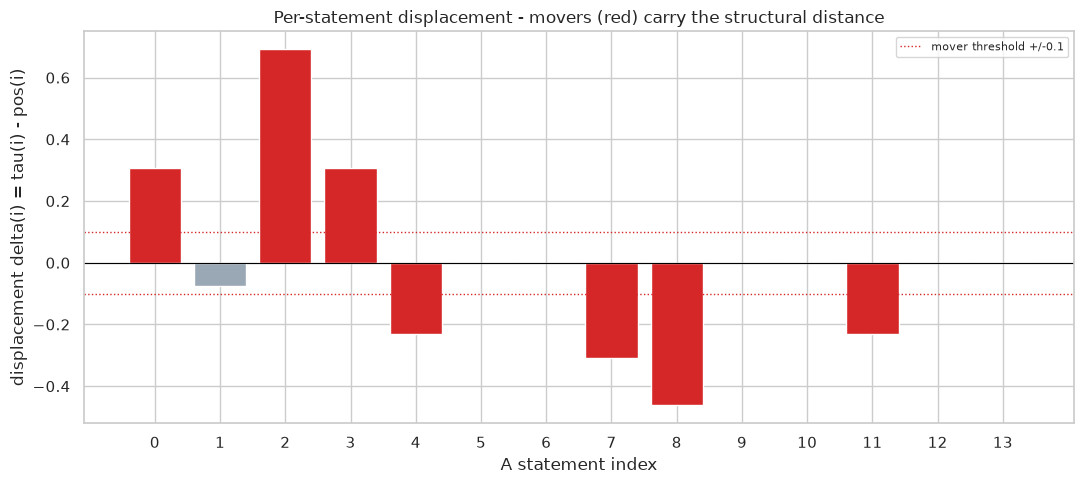

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#d62728" if m else "#9aa7b4" for m in movers_df["mover"]]
ax.bar(movers_df["i"], movers_df["delta"], color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.axhline(MOVER_THRESH, color="#d62728", ls=":", lw=1, label=f"mover threshold +/-{MOVER_THRESH}")
ax.axhline(-MOVER_THRESH, color="#d62728", ls=":", lw=1)
ax.set(xlabel="A statement index", ylabel="displacement delta(i) = tau(i) - pos(i)",
       title="Per-statement displacement - movers (red) carry the structural distance")
ax.set_xticks(movers_df["i"]); ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); fig.savefig(FIGDIR / "12-displacement.png", dpi=120, bbox_inches="tight"); plt.show()

## Conclusion

In [13]:
ro = readout.set_index("pair")
summary = (
    f"Reordered-but-faithful: semantic closeness {ro.loc['reordered-but-faithful','sem closeness']:.3f} "
    f"(content preserved) vs structural closeness {ro.loc['reordered-but-faithful','struct closeness']:.3f} "
    f"(arrangement changed) - the structure axis adds the signal SMD misses.\n"
    f"Different-content: semantic closeness {ro.loc['different-content','sem closeness']:.3f} - SMD fires on content drift.\n"
    f"Identity: semantic {ro.loc['identity','sem closeness']:.3f} / structural {ro.loc['identity','struct closeness']:.3f} - both saturate.\n"
    f"Structural mapping recovered: {n_movers}/{len(STA)} statements flagged as movers off the transport plan."
)
console.print(summary, style="bold green")

Reordered-but-faithful: semantic closeness 1.000 (content preserved) vs structural closeness 0.934 (arrangement 
changed) - the structure axis adds the signal SMD misses.
Different-content: semantic closeness 0.738 - SMD fires on content drift.
Identity: semantic 1.000 / structural 1.000 - both saturate.
Structural mapping recovered: 7/14 statements flagged as movers off the transport plan.

**The structural mapping is recovered from the transport plan, and the two axes separate content drift from rearrangement.**

- **The reordered-but-faithful pair is the proof point** - semantic closeness saturates near 1.0 (the statements are byte-identical,
  only reordered, so SMD reads them as the same content) while structural closeness drops below it - the position-augmented
  Wasserstein at `lambda=0.25` registers the rearrangement SMD is blind to by construction
- **The different-content pair shows SMD firing** - semantic closeness falls well under 1.0 when the content genuinely differs, so
  the semantic axis is doing its job; the identity pair saturates both axes at closeness 1.0 as a sanity floor
- **One object, two settings** - both numbers come off the same mmBERT embeddings and the same `ot.emd2` solver; `lambda=0` is SMD,
  `lambda=0.25` is the structural generalization, reported side by side as the two-axis readout
- **Interpretability is `O(n)` off the plan** - the movers table names which statements moved and where: each A-statement's matched
  B-statement, its induced position `tau(i)` and displacement `delta(i)`, with the largest movers carrying the structural distance.
  This is the structural analogue of SMD's transport-map JSON